In [6]:
import gym


#定义环境
class MyWrapper(gym.Wrapper):

    def __init__(self):
        env = gym.make('Pendulum-v1', render_mode='rgb_array')
        super().__init__(env)
        self.env = env
        self.step_n = 0

    def reset(self):
        state, _ = self.env.reset()
        self.step_n = 0
        return state

    def step(self, action):
        state, reward, terminated, truncated, info = self.env.step(action)
        done = terminated or truncated
        self.step_n += 1
        if self.step_n >= 200:
            done = True
        return state, reward, done, info


env = MyWrapper()

env.reset()

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


array([ 0.86696357, -0.4983715 , -0.925365  ], dtype=float32)

<frozen importlib._bootstrap>:228: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\SJC\.conda\envs\py39\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


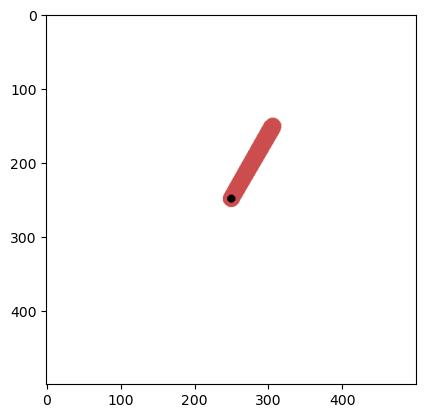

In [11]:
from matplotlib import pyplot as plt

%matplotlib inline


#打印游戏
def show():
    plt.imshow(env.render())
    plt.show()


show()

In [13]:
import torch
import random
from IPython import display


#定义模型
class Model(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.fc_statu = torch.nn.Sequential(
            torch.nn.Linear(3, 128),
            torch.nn.ReLU(),
        )

        self.fc_mu = torch.nn.Sequential(
            torch.nn.Linear(128, 1),
            torch.nn.Tanh(),
        )

        self.fc_std = torch.nn.Sequential(
            torch.nn.Linear(128, 1),
            torch.nn.Softplus(),
        )

    def forward(self, state):
        state = self.fc_statu(state)

        mu = self.fc_mu(state) * 2.0
        std = self.fc_std(state)

        return mu, std


class PPO:

    def __init__(self):
        #定义模型
        self.model = Model()

        self.model_td = torch.nn.Sequential(
            torch.nn.Linear(3, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1),
        )

        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=1e-4)
        self.optimizer_td = torch.optim.Adam(self.model_td.parameters(),
                                             lr=5e-3)
        self.loss_fn = torch.nn.MSELoss()

    def get_action(self, state):
        state = torch.FloatTensor(state).reshape(1, 3)
        mu, std = self.model(state)

        #根据概率选择一个动作
        #action = random.normalvariate(mu=mu.item(), sigma=std.item())
        action = torch.distributions.Normal(mu, std).sample().item()

        return action

    def get_data(self):
        states = []
        rewards = []
        actions = []
        next_states = []
        overs = []

        #初始化游戏
        state = env.reset()

        #玩到游戏结束为止
        over = False
        while not over:
            #根据当前状态得到一个动作
            action = self.get_action(state)

            #执行动作,得到反馈
            next_state, reward, over, _ = env.step([action])

            #记录数据样本
            states.append(state)
            rewards.append(reward)
            actions.append(action)
            next_states.append(next_state)
            overs.append(over)

            #更新游戏状态,开始下一个动作
            state = next_state

        #[b, 3]
        states = torch.FloatTensor(states).reshape(-1, 3)
        #[b, 1]
        rewards = torch.FloatTensor(rewards).reshape(-1, 1)
        #[b, 1]
        actions = torch.FloatTensor(actions).reshape(-1, 1)
        #[b, 3]
        next_states = torch.FloatTensor(next_states).reshape(-1, 3)
        #[b, 1]
        overs = torch.LongTensor(overs).reshape(-1, 1)

        return states, rewards, actions, next_states, overs

    def test(self, play):
        #初始化游戏
        state = env.reset()

        #记录反馈值的和,这个值越大越好
        reward_sum = 0

        #玩到游戏结束为止
        over = False
        while not over:
            #根据当前状态得到一个动作
            action = self.get_action(state)

            #执行动作,得到反馈
            state, reward, over, _ = env.step([action])
            reward_sum += reward

            #打印动画
            if play and random.random() < 0.2:  #跳帧
                display.clear_output(wait=True)
                show()

        return reward_sum

    #优势函数
    def get_advantages(self, deltas):
        advantages = []

        #反向遍历deltas
        s = 0.0
        for delta in deltas[::-1]:
            s = 0.9 * 0.9 * s + delta
            advantages.append(s)

        #逆序
        advantages.reverse()
        return advantages
    
    def train(self, states, rewards, actions, next_states, overs):
        #偏移reward,便于训练
        rewards = (rewards + 8) / 8

        #计算values和targets
        #[b, 3] -> [b, 1]
        values = self.model_td(states)

        #[b, 3] -> [b, 1]
        targets = self.model_td(next_states).detach()
        targets = targets * 0.98
        targets *= (1 - overs)
        targets += rewards

        #计算优势,这里的advantages有点像是策略梯度里的reward_sum
        #只是这里计算的不是reward,而是target和value的差
        #[b, 1]
        deltas = (targets - values).squeeze(dim=1).tolist()
        advantages = self.get_advantages(deltas)
        advantages = torch.FloatTensor(advantages).reshape(-1, 1)

        #取出每一步动作的概率
        #[b, 3] -> [b, 1],[b, 1]
        mu, std = self.model(states)
        #[b, 1]
        old_probs = torch.distributions.Normal(mu, std)
        old_probs = old_probs.log_prob(actions).exp().detach()

        #每批数据反复训练10次
        for _ in range(10):
            #重新计算每一步动作的概率
            #[b, 3] -> [b, 1],[b, 1]
            mu, std = self.model(states)
            #[b, 1]
            new_probs = torch.distributions.Normal(mu, std)
            new_probs = new_probs.log_prob(actions).exp()

            #求出概率的变化
            #[b, 1] - [b, 1] -> [b, 1]
            ratios = new_probs / old_probs

            #计算截断的和不截断的两份loss,取其中小的
            #[b, 1] * [b, 1] -> [b, 1]
            surr1 = ratios * advantages
            #[b, 1] * [b, 1] -> [b, 1]
            surr2 = torch.clamp(ratios, 0.8, 1.2) * advantages

            loss = -torch.min(surr1, surr2)
            loss = loss.mean()

            #重新计算value,并计算时序差分loss
            values = self.model_td(states)
            loss_td = self.loss_fn(values, targets)

            #更新参数
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            self.optimizer_td.zero_grad()
            loss_td.backward()
            self.optimizer_td.step()


teacher = PPO()

teacher.train(*teacher.get_data())

teacher.get_action([1, 2, 3]), teacher.test(play=False)

c:\Users\SJC\.conda\envs\py39\lib\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):
C:\Users\SJC\AppData\Local\Temp\ipykernel_16148\3166162692.py:92: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:281.)
  states = torch.FloatTensor(states).reshape(-1, 3)


(0.9507049918174744, -1400.6244306809335)

In [14]:
for i in range(6000):
    teacher.train(*teacher.get_data())

    if i % 500 == 0:
        test_result = sum([teacher.test(play=False) for _ in range(10)]) / 10
        print(i, test_result)

teacher.test(play=False)

0 -1688.5815268279869
500 -1147.1677626954177


KeyboardInterrupt: 

In [15]:
#初始化学生模型
student = PPO()

student

In [16]:
#定义鉴别器网络,它的任务是鉴定一批数据是出自teacher还是student
class Discriminator(torch.nn.Module):

    def __init__(self):
        super().__init__()
        self.sequential = torch.nn.Sequential(
            torch.nn.Linear(4, 128),
            torch.nn.ReLU(),
            torch.nn.Linear(128, 1),
            torch.nn.Sigmoid(),
        )

    def forward(self, states, actions):
        cat = torch.cat([states, actions], dim=1)

        return self.sequential(cat)


discriminator = Discriminator()

discriminator(torch.randn(2, 3), torch.randn(2, 1))

tensor([[0.4125],
        [0.4372]], grad_fn=<SigmoidBackward0>)

In [17]:
#模仿学习
def copy_learn():
    optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)
    bce_loss = torch.nn.BCELoss()

    for i in range(20000):
        #使用训练好的模型获取一批教师数据
        with torch.no_grad():
            teacher_states, _, teacher_actions, _, _ = teacher.get_data()

        #使用学生模型获取一局游戏的数据,不需要reward
        states, _, actions, next_states, overs = student.get_data()

        #使用鉴别器鉴定两批数据是来自教师的还是学生的
        prob_teacher = discriminator(teacher_states, teacher_actions)
        prob_student = discriminator(states, actions)

        #老师的用0表示,学生的用1表示,计算二分类loss
        loss_teacher = bce_loss(prob_teacher, torch.zeros_like(prob_teacher))
        loss_student = bce_loss(prob_student, torch.ones_like(prob_student))
        loss = loss_teacher + loss_student

        #调整鉴别器的loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        #使用一批数据来自学生的概率作为reward,取log,再符号取反
        #因为鉴别器会把学生数据的概率贴近1,所以目标是让鉴别器无法分辨,这是一种对抗网络的思路
        rewards = -prob_student.log().detach()

        #消除模型中的reward偏移
        rewards = rewards * 8 - 8

        #更新学生模型参数,使用PPO模型本身的更新方式
        student.train(states, rewards, actions, next_states, overs)

        if i % 500 == 0:
            test_result = sum([student.test(play=False)
                               for _ in range(10)]) / 10

            print(i, test_result)


copy_learn()

0 -1442.8494910791135


KeyboardInterrupt: 

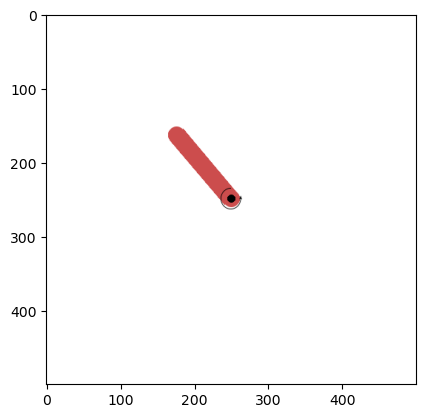

-1569.4313867191738

In [18]:
student.test(play=True)